In [1]:
import os
import pandas as pd
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

import cv2
import certifi
import mediapipe as mp
import urllib.request
from mpl_toolkits.mplot3d import Axes3D


In [2]:

print("NumPy:", np.__version__)
print("MediaPipe:", mp.__version__)
print("OpenCV:", cv2.__version__)

NumPy: 1.26.4
MediaPipe: 0.10.9
OpenCV: 4.13.0


In [3]:
# certifi.where() returns the path to certifi's certificate bundle file.
# Example:
# /Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/certifi/cacert.pem

cert_path = certifi.where()

# SSL_CERT_FILE tells Python/SSL-based libraries:
# "When making HTTPS requests, use this certificate bundle to verify websites."
os.environ["SSL_CERT_FILE"] = cert_path

# REQUESTS_CA_BUNDLE tells the requests library:
# "When making HTTPS requests, use this certificate bundle to verify websites."
# This is useful because some packages use requests under the hood.
os.environ["REQUESTS_CA_BUNDLE"] = cert_path

# Print the paths so we can confirm the environment variables are set.
print("SSL_CERT_FILE:", os.environ["SSL_CERT_FILE"])
print("REQUESTS_CA_BUNDLE:", os.environ["REQUESTS_CA_BUNDLE"])

SSL_CERT_FILE: /Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/certifi/cacert.pem
REQUESTS_CA_BUNDLE: /Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/certifi/cacert.pem


In [4]:

response = urllib.request.urlopen("https://www.google.com")
print(response.status)

200


In [5]:
NOTEBOOK_DIR = os.getcwd()

# golfDB.mat is bundled in this folder
GOLFDB_MAT = os.path.join(NOTEBOOK_DIR, "golfDB.mat")

# Videos live in the main team repo, cloned alongside this folder
VIDEO_DIR = os.path.abspath(os.path.join(
    NOTEBOOK_DIR, "..",
    "Data", "videos_160"
))

print("GOLFDB_MAT:", GOLFDB_MAT, "| exists:", os.path.exists(GOLFDB_MAT))
print("VIDEO_DIR: ", VIDEO_DIR,  "| exists:", os.path.exists(VIDEO_DIR))

GOLFDB_MAT: /Users/austinblee/github/capstone/SinglePOVGolfSwingReconstructionUsingSimulatedBiomechanicalAI/AL EDA Investigation/golfDB.mat | exists: True
VIDEO_DIR:  /Users/austinblee/github/capstone/SinglePOVGolfSwingReconstructionUsingSimulatedBiomechanicalAI/Data/videos_160 | exists: True


In [6]:
mat = sio.loadmat(GOLFDB_MAT)
print(mat.keys())

golfdb = mat["golfDB"]

print(type(golfdb))
print(golfdb.shape)
print(golfdb.dtype)
print(golfdb.dtype.names)

dict_keys(['__header__', '__version__', '__globals__', 'golfDB'])
<class 'numpy.ndarray'>
(1, 1400)
[('id', 'O'), ('youtube_id', 'O'), ('player', 'O'), ('sex', 'O'), ('club', 'O'), ('view', 'O'), ('slow', 'O'), ('events', 'O'), ('bbox', 'O'), ('split', 'O')]
('id', 'youtube_id', 'player', 'sex', 'club', 'view', 'slow', 'events', 'bbox', 'split')


In [7]:

def unwrap(x):
    """
    Makes MATLAB-loaded arrays easier to inspect.
    """
    while isinstance(x, np.ndarray) and x.size == 1:
        x = x.item()
    return x


# first three records
for i in range(3):
    record = golfdb[0, i]

    print(f"\n========== RECORD {i} ==========")

    for field in golfdb.dtype.names:
        value = unwrap(record[field])
        print(f"{field}: {value}")


========== RECORD 0 ==========
id: 0
youtube_id: f1BWA5F87Jc
player: SANDRA GAL
sex: f
club: driver
view: down-the-line
slow: 0
events: [[408 455 473 476 490 495 498 501 514 545]]
bbox: [[0.09765625 0.00694444 0.50234375 0.98055556]]
split: 3

========== RECORD 1 ==========
id: 1
youtube_id: f1BWA5F87Jc
player: SANDRA GAL
sex: f
club: driver
view: down-the-line
slow: 1
events: [[ 814  854  917  931  988 1006 1019 1030 1083 1137]]
bbox: [[3.90625000e-02 6.94444444e-04 6.12500000e-01 9.78472222e-01]]
split: 3

========== RECORD 2 ==========
id: 2
youtube_id: tA1iotgtMyc
player: CHRIS DIMARCO
sex: m
club: driver
view: down-the-line
slow: 0
events: [[521 659 678 683 692 696 698 701 715 745]]
bbox: [[1.65625000e-01 6.94444444e-04 4.83593750e-01 9.86805556e-01]]
split: 3


In [8]:
#set up df
rows = [] 
for i in range(golfdb.shape[1]):
    record = golfdb[0, i]
    row = {}
    for field in golfdb.dtype.names:
        row[field] = unwrap(record[field])
    rows.append(row)
#create df    
df = pd.DataFrame(rows)

df.head()

,id,youtube_id,player,sex,club,view,slow,events,bbox,split
0,0,f1BWA5F87Jc,SANDRA GAL,f,driver,down-the-line,0,"[[408, 455, 473, 476, 490, 495, 498, 501, 514,...","[[0.09765625000000001, 0.006944444444444444, 0...",3
1,1,f1BWA5F87Jc,SANDRA GAL,f,driver,down-the-line,1,"[[814, 854, 917, 931, 988, 1006, 1019, 1030, 1...","[[0.039062500000000014, 0.0006944444444444445,...",3
2,2,tA1iotgtMyc,CHRIS DIMARCO,m,driver,down-the-line,0,"[[521, 659, 678, 683, 692, 696, 698, 701, 715,...","[[0.165625, 0.0006944444444444445, 0.48359375,...",3
3,3,tA1iotgtMyc,CHRIS DIMARCO,m,driver,down-the-line,1,"[[1106, 1190, 1244, 1264, 1300, 1313, 1324, 13...","[[0.18515625, 0.0006944444444444445, 0.465625,...",3
4,4,wDCKLePrwHA,BROOKE HENDERSON,f,driver,down-the-line,0,"[[157, 170, 183, 188, 197, 201, 205, 207, 220,...","[[0.11015625, 0.0006944444444444445, 0.4984375...",3


In [9]:
print(df.columns)

# How many videos?
print("Number of records:", len(df))

print("\nViews:")
if "view" in df.columns:
    print(df["view"].value_counts())
else:
    print("no view column")
    
print("\nClubs:")
if "club" in df.columns:
    print(df["club"].value_counts())
else:
    print("no club column")

print("\nPlayers:")
if "player" in df.columns:
    print(df["player"].value_counts().head(20))
else:
    print("no player column")    

if "events" in df.columns:
    print(df["events"].head(10))
else:
    print("No events column found")

Index(['id', 'youtube_id', 'player', 'sex', 'club', 'view', 'slow', 'events',
       'bbox', 'split'],
      dtype='object')
Number of records: 1400

Views:
view
down-the-line    585
face-on          461
other            354
Name: count, dtype: int64

Clubs:
club
driver     952
iron       229
fairway    162
hybrid      34
wedge       23
Name: count, dtype: int64

Players:
player
LYDIA KO            58
MICHELLE WIE        54
TIGER WOODS         53
BROOKE HENDERSON    35
RORY MCILROY        27
INBEE PARK          23
LEXI THOMPSON       23
PAULA CREAMER       21
GRAEME MCDOWELL     19
RICKIE FOWLER       18
CHARLEY HULL        17
BERNHARD LANGER     17
ADAM SCOTT          17
SANDRA GAL          16
JUSTIN ROSE         16
SEAN OHAIR          15
HENRIK STENSON      15
BUBBA WATSON        14
FRED COUPLES        14
STACY LEWIS         13
Name: count, dtype: int64
0    [[408, 455, 473, 476, 490, 495, 498, 501, 514,...
1    [[814, 854, 917, 931, 988, 1006, 1019, 1030, 1...
2    [[521, 659, 678, 

In [10]:
events = df.loc[0, "events"]
events_flat = np.array(events).flatten()

print(events_flat)
print("Number of events:", len(events_flat))

[408 455 473 476 490 495 498 501 514 545]
Number of events: 10


In [11]:
video_id = 578

video_path = f"{VIDEO_DIR}/{video_id}.mp4"

# Pull the event annotations for this video from the dataframe.
# df.loc[video_id, "events"] gives us the event frame labels for video 578.
# np.array(...).flatten() turns the nested MATLAB-style structure into a simple 1D array.
# astype(int) makes sure the frame numbers are integers.

events = np.array(df.loc[video_id, "events"]).flatten().astype(int)

# Open the video file with OpenCV.
cap = cv2.VideoCapture(video_path)

# Get the number of frames in the actual video file.
# For example, video 578 has 446 frames, meaning valid local frame numbers are 0 to 445.

frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Close the video file after checking metadata.
cap.release()

# Print basic diagnostic information.
print("Video:", video_path)
print("Frame count:", frame_count)
print("Events:", events)
print("Max event frame:", events.max())

# This checks whether the event frame numbers fit inside the video file.
# If max event frame is greater than or equal to frame_count, then the event labels
# cannot be directly used as local video frame numbers.

if events.max() >= frame_count:
    print("Problem: event frame numbers are larger than the video length.")
else:
    print("Looks okay: event frames fit inside the video.")

Video: /Users/austinblee/github/capstone/SinglePOVGolfSwingReconstructionUsingSimulatedBiomechanicalAI/Data/videos_160/578.mp4
Frame count: 446
Events: [151 461 489 493 502 507 510 513 536 596]
Max event frame: 596
Problem: event frame numbers are larger than the video length.


Golfdb stores event annotations using original video frame timelines. As such frames start at 0, not the event frame timeline


Video: /Users/austinblee/github/capstone/SinglePOVGolfSwingReconstructionUsingSimulatedBiomechanicalAI/Data/videos_160/578.mp4
Frame count: 446
Original events: [151 461 489 493 502 507 510 513 536 596]
Relative events: [  0 310 338 342 351 356 359 362 385 445]
Max relative event: 445
Good: relative events fit inside the video.


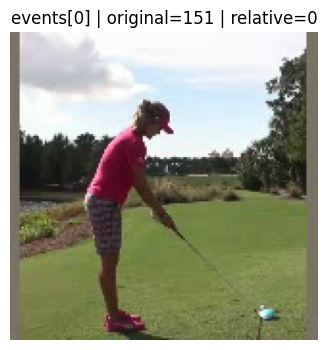

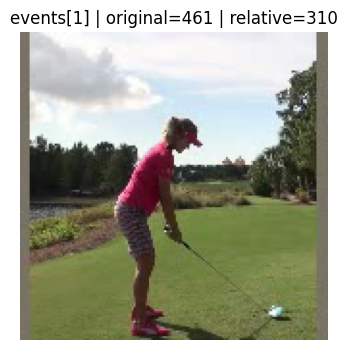

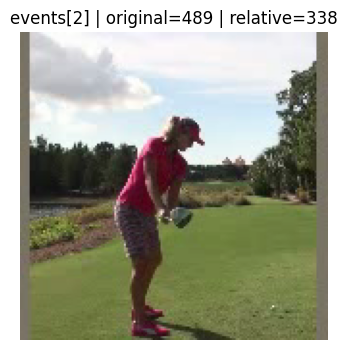

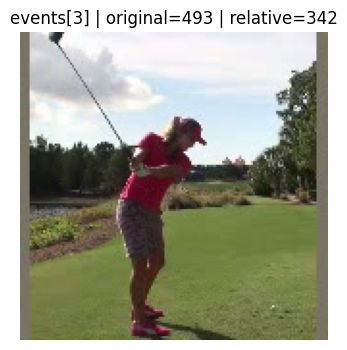

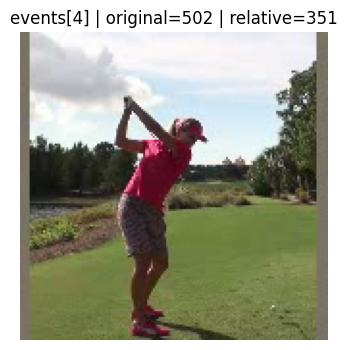

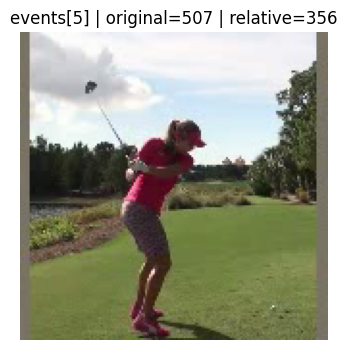

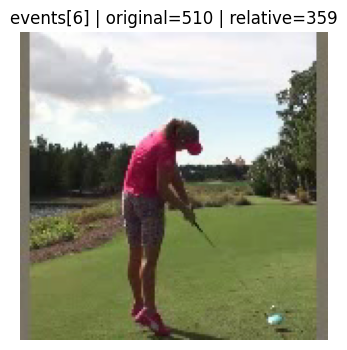

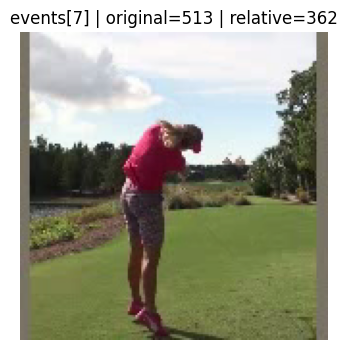

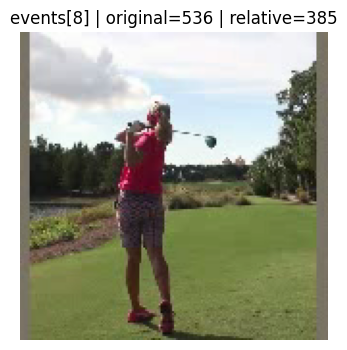

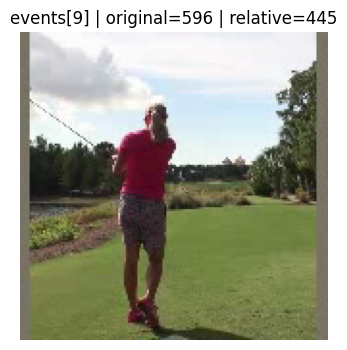

In [12]:
# Re-define the video ID and path.
# This is repeated here so this cell can run independently.
video_id = 578
video_path = f"{VIDEO_DIR}/{video_id}.mp4"

# Load original event annotations again.
# These are original/source-video frame numbers, not local trimmed-video frame numbers.
events_original = np.array(df.loc[video_id, "events"]).flatten().astype(int)

# Convert original frame numbers into local frame numbers.
# The first event marker appears to represent the start of the trimmed clip.
# So subtracting events_original[0] shifts the timeline so the clip starts at frame 0.
events_relative = events_original - events_original[0]

# Example:
# original events: [151, 461, 489, ..., 596]
# subtract 151:    [0,   310, 338, ..., 445]
#
# Now the relative event frames fit inside the 446-frame local video.

# Open the video again.
cap = cv2.VideoCapture(video_path)

# Get the frame count again for validation.
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Print diagnostics.
print("Video:", video_path)
print("Frame count:", frame_count)
print("Original events:", events_original)
print("Relative events:", events_relative)
print("Max relative event:", events_relative.max())

# Check whether the shifted/relative event frames now fit inside the video.
if events_relative.max() >= frame_count:
    print("Still a problem: relative event frame exceeds video length.")
else:
    print("Good: relative events fit inside the video.")

# Loop through each event frame and display the corresponding video frame.
for idx, frame_num in enumerate(events_relative):

    # Move the video reader to the target frame.
    # Important: this now uses the relative/local frame number.
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_num))

    # Read the frame at that position.
    ret, frame = cap.read()

    # If OpenCV cannot read the frame, print a message and skip it.
    if not ret:
        print(f"Could not read event {idx}, relative frame {frame_num}")
        continue

    # OpenCV reads images in BGR color format.
    # Matplotlib expects RGB, so we convert before displaying.
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Plot the frame.
    plt.figure(figsize=(4, 4))
    plt.imshow(frame)

    # Show both the original annotation frame and the local/relative frame.
    plt.title(
        f"events[{idx}] | original={events_original[idx]} | relative={frame_num}"
    )
    plt.axis("off")
    plt.show()

# Close the video file after reading frames.
cap.release()

In [13]:


video_dir = VIDEO_DIR

print("VIDEO_DIR:", video_dir)

if os.path.exists(video_dir):
    files = [f for f in os.listdir(video_dir) if f.endswith(".mp4")]
    print("\nNumber of videos:", len(files))
    print("First 10 files:", files[:10])

    video_path = os.path.join(video_dir, files[0])
    print("\nTesting video:", video_path)
    print("Exists?", os.path.exists(video_path))

    cap = cv2.VideoCapture(video_path)
    print("Opened?", cap.isOpened())
    print("Frame count:", int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))
    print("FPS:", cap.get(cv2.CAP_PROP_FPS))
    cap.release()
else:
    print("\nNo videos_160 folder found.")

VIDEO_DIR: /Users/austinblee/github/capstone/SinglePOVGolfSwingReconstructionUsingSimulatedBiomechanicalAI/Data/videos_160

Number of videos: 1400
First 10 files: ['578.mp4', '544.mp4', '222.mp4', '236.mp4', '550.mp4', '1013.mp4', '587.mp4', '593.mp4', '1007.mp4', '746.mp4']

Testing video: /Users/austinblee/github/capstone/SinglePOVGolfSwingReconstructionUsingSimulatedBiomechanicalAI/Data/videos_160/578.mp4
Exists? True
Opened? True
Frame count: 446
FPS: 29.97


In [14]:

os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()

print("SSL_CERT_FILE:", os.environ["SSL_CERT_FILE"])
print("REQUESTS_CA_BUNDLE:", os.environ["REQUESTS_CA_BUNDLE"])

SSL_CERT_FILE: /Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/certifi/cacert.pem
REQUESTS_CA_BUNDLE: /Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/certifi/cacert.pem


In [15]:
mp_pose = mp.solutions.pose

def extract_pose_from_video(video_path, video_id):
    rows = []

    cap = cv2.VideoCapture(video_path)

    with mp_pose.Pose(
        static_image_mode=False,
        model_complexity=2,
        enable_segmentation=False,
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5,
    ) as pose:

        frame_idx = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = pose.process(rgb)

            if results.pose_landmarks:
                for joint_idx, landmark in enumerate(results.pose_landmarks.landmark):
                    rows.append({
                        "video_id": video_id,
                        "frame_idx": frame_idx,
                        "joint_idx": joint_idx,
                        "x": landmark.x,
                        "y": landmark.y,
                        "z": landmark.z,
                        "visibility": landmark.visibility,
                    })

            frame_idx += 1

    cap.release()
    return pd.DataFrame(rows)

In [16]:
pose_df = extract_pose_from_video(f"{VIDEO_DIR}/578.mp4", "578")
pose_df.head()

I0000 00:00:1780242728.143734       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M5
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


,video_id,frame_idx,joint_idx,x,y,z,visibility
0,578,0,0,0.490986,0.311715,-0.058259,0.999785
1,578,0,1,0.487572,0.295033,-0.049109,0.999621
2,578,0,2,0.484935,0.293201,-0.049534,0.999687
3,578,0,3,0.482369,0.291674,-0.049379,0.999727
4,578,0,4,0.487801,0.295478,-0.096473,0.999702


In [17]:
mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils
mp_styles = mp.solutions.drawing_styles

def show_pose_overlay(video_path, frame_idx, title=None):
    """
    Reads one frame from a video, runs MediaPipe Pose on that frame,
    and displays the frame with the pose skeleton overlaid.
    """

    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))

    ret, frame = cap.read()
    cap.release()

    if not ret:
        print(f"Could not read frame {frame_idx}")
        return

    # OpenCV reads in BGR; MediaPipe / matplotlib expect RGB.
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    with mp_pose.Pose(
        static_image_mode=True,
        model_complexity=2,
        enable_segmentation=False,
        min_detection_confidence=0.5
    ) as pose:

        results = pose.process(rgb)

        annotated = rgb.copy()

        if results.pose_landmarks:
            mp_drawing.draw_landmarks(
                annotated,
                results.pose_landmarks,
                mp_pose.POSE_CONNECTIONS,
                landmark_drawing_spec=mp_styles.get_default_pose_landmarks_style()
            )

            plt.figure(figsize=(6, 6))
            plt.imshow(annotated)
            plt.title(title if title else f"Pose overlay | frame {frame_idx}")
            plt.axis("off")
            plt.show()

        else:
            print(f"No pose detected on frame {frame_idx}")

In [18]:
video_id = 578

events_original = np.array(df.loc[video_id, "events"]).flatten().astype(int)
events_relative = events_original - events_original[0]

event_names_10 = [
    "Clip start",
    "Address",
    "Toe-up",
    "Mid-backswing",
    "Top",
    "Mid-downswing",
    "Impact",
    "Mid-follow-through",
    "Finish",
    "Clip end"
]

for name, original, relative in zip(event_names_10, events_original, events_relative):
    print(f"{name}: original frame {original}, local frame {relative}")

Clip start: original frame 151, local frame 0
Address: original frame 461, local frame 310
Toe-up: original frame 489, local frame 338
Mid-backswing: original frame 493, local frame 342
Top: original frame 502, local frame 351
Mid-downswing: original frame 507, local frame 356
Impact: original frame 510, local frame 359
Mid-follow-through: original frame 513, local frame 362
Finish: original frame 536, local frame 385
Clip end: original frame 596, local frame 445


I0000 00:00:1780242751.721317       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M5


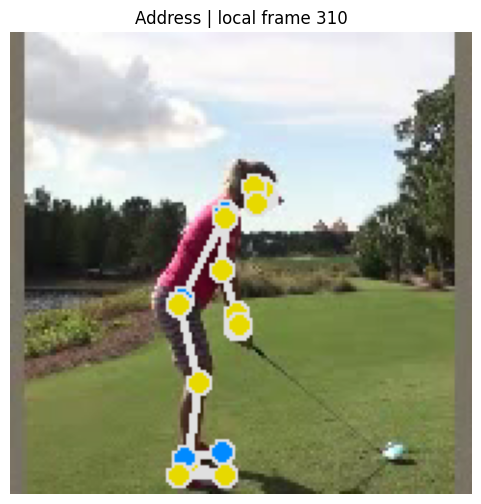

I0000 00:00:1780242752.013487       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M5


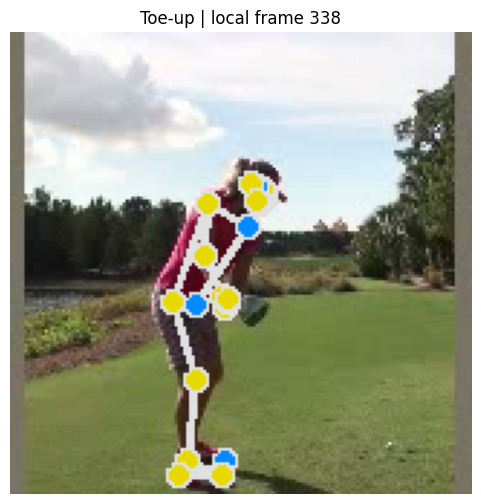

I0000 00:00:1780242752.293131       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M5


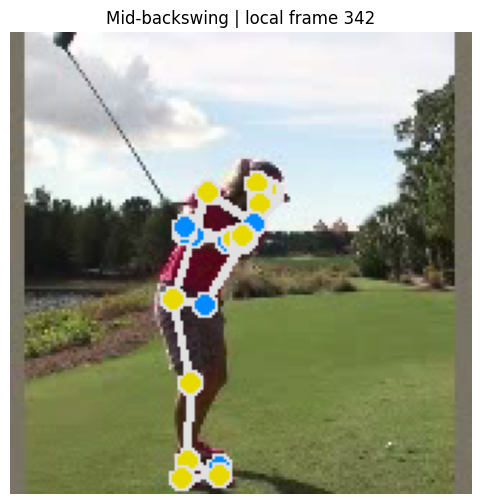

I0000 00:00:1780242752.595904       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M5


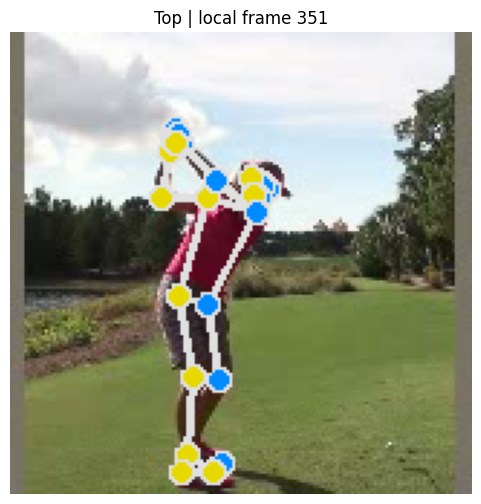

I0000 00:00:1780242752.985159       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M5


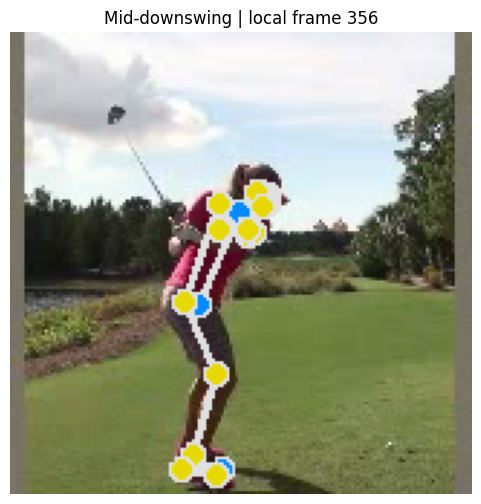

I0000 00:00:1780242753.280108       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M5


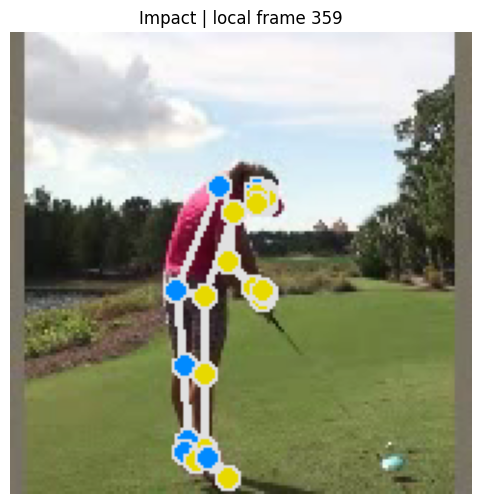

I0000 00:00:1780242753.559272       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M5


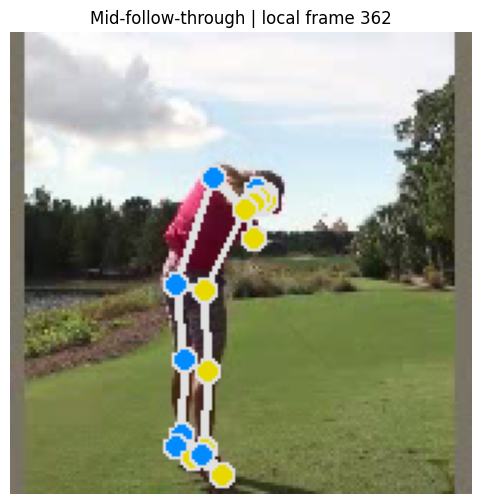

I0000 00:00:1780242753.906437       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M5


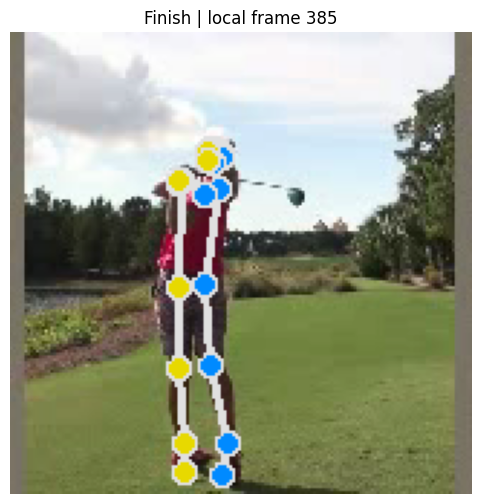

In [19]:
swing_event_names = [
    "Address",
    "Toe-up",
    "Mid-backswing",
    "Top",
    "Mid-downswing",
    "Impact",
    "Mid-follow-through",
    "Finish"
]

swing_event_frames = events_relative[1:9]

for name, frame_idx in zip(swing_event_names, swing_event_frames):
    show_pose_overlay(
        video_path,
        frame_idx,
        title=f"{name} | local frame {frame_idx}"
    )

In [20]:


mp_pose = mp.solutions.pose

def extract_pose_from_video_with_world(video_path, video_id):
    image_rows = []
    world_rows = []

    cap = cv2.VideoCapture(video_path)

    with mp_pose.Pose(
        static_image_mode=False,
        model_complexity=2,
        enable_segmentation=False,
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5,
    ) as pose:

        frame_idx = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = pose.process(rgb)

            # 2D image-space landmarks + relative z
            if results.pose_landmarks:
                for joint_idx, landmark in enumerate(results.pose_landmarks.landmark):
                    image_rows.append({
                        "video_id": video_id,
                        "frame_idx": frame_idx,
                        "joint_idx": joint_idx,
                        "coord_type": "image",
                        "x": landmark.x,
                        "y": landmark.y,
                        "z": landmark.z,
                        "visibility": landmark.visibility,
                    })

            # Estimated 3D world/body-space landmarks
            if results.pose_world_landmarks:
                for joint_idx, landmark in enumerate(results.pose_world_landmarks.landmark):
                    world_rows.append({
                        "video_id": video_id,
                        "frame_idx": frame_idx,
                        "joint_idx": joint_idx,
                        "coord_type": "world",
                        "x": landmark.x,
                        "y": landmark.y,
                        "z": landmark.z,
                        "visibility": landmark.visibility,
                    })

            frame_idx += 1

    cap.release()

    image_df = pd.DataFrame(image_rows)
    world_df = pd.DataFrame(world_rows)

    return image_df, world_df

In [21]:
image_pose_df, world_pose_df = extract_pose_from_video_with_world(
    f"{VIDEO_DIR}/578.mp4",
    "578"
)

image_pose_df.head(), world_pose_df.head()

I0000 00:00:1780242754.198745       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M5


(  video_id  frame_idx  joint_idx coord_type         x         y         z  \
 0      578          0          0      image  0.490986  0.311715 -0.058259   
 1      578          0          1      image  0.487572  0.295033 -0.049109   
 2      578          0          2      image  0.484935  0.293201 -0.049534   
 3      578          0          3      image  0.482369  0.291674 -0.049379   
 4      578          0          4      image  0.487801  0.295478 -0.096473   
 
    visibility  
 0    0.999785  
 1    0.999621  
 2    0.999687  
 3    0.999727  
 4    0.999702  ,
   video_id  frame_idx  joint_idx coord_type         x         y         z  \
 0      578          0          0      world  0.373855 -0.455969 -0.124029   
 1      578          0          1      world  0.375308 -0.493077 -0.127948   
 2      578          0          2      world  0.376784 -0.492092 -0.116547   
 3      578          0          3      world  0.377335 -0.492801 -0.120574   
 4      578          0          4    

In [22]:

mp_pose = mp.solutions.pose

def extract_world_pose_for_frame(video_path, frame_idx, video_id="unknown"):
    rows = []

    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))

    ret, frame = cap.read()
    cap.release()

    if not ret:
        print(f"Could not read frame {frame_idx}")
        return pd.DataFrame()

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    with mp_pose.Pose(
        static_image_mode=True,
        model_complexity=2,
        enable_segmentation=False,
        min_detection_confidence=0.5
    ) as pose:

        results = pose.process(rgb)

        if not results.pose_world_landmarks:
            print(f"No world landmarks found for frame {frame_idx}")
            return pd.DataFrame()

        for joint_idx, landmark in enumerate(results.pose_world_landmarks.landmark):
            rows.append({
                "video_id": video_id,
                "frame_idx": frame_idx,
                "joint_idx": joint_idx,
                "x": landmark.x,
                "y": landmark.y,
                "z": landmark.z,
                "visibility": landmark.visibility
            })

    return pd.DataFrame(rows)

In [23]:
video_path = f"{VIDEO_DIR}/578.mp4"

# Example: visualize the Address frame
frame_to_view = int(events_relative[1])

world_frame_df = extract_world_pose_for_frame(
    video_path,
    frame_to_view,
    video_id="578"
)

world_frame_df.head()

I0000 00:00:1780242777.963320       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M5


,video_id,frame_idx,joint_idx,x,y,z,visibility
0,578,310,0,0.396815,-0.439182,-0.108035,0.999761
1,578,310,1,0.400752,-0.476489,-0.106115,0.999489
2,578,310,2,0.403066,-0.475326,-0.095087,0.999546
3,578,310,3,0.403461,-0.475371,-0.099521,0.999609
4,578,310,4,0.407464,-0.477403,-0.149209,0.999673


In [24]:
landmark_names = {
    i: landmark.name
    for i, landmark in enumerate(mp_pose.PoseLandmark)
}

world_frame_df["joint_name"] = world_frame_df["joint_idx"].map(landmark_names)

world_frame_df.head()

,video_id,frame_idx,joint_idx,x,y,z,visibility,joint_name
0,578,310,0,0.396815,-0.439182,-0.108035,0.999761,NOSE
1,578,310,1,0.400752,-0.476489,-0.106115,0.999489,LEFT_EYE_INNER
2,578,310,2,0.403066,-0.475326,-0.095087,0.999546,LEFT_EYE
3,578,310,3,0.403461,-0.475371,-0.099521,0.999609,LEFT_EYE_OUTER
4,578,310,4,0.407464,-0.477403,-0.149209,0.999673,RIGHT_EYE_INNER


In [25]:
from mpl_toolkits.mplot3d import Axes3D

def plot_world_pose_3d(world_df, title="Estimated 3D World Pose"):
    """
    Visualizes MediaPipe pose_world_landmarks as a 3D skeleton.
    """

    if world_df.empty:
        print("world_df is empty.")
        return

    # Make lookup from joint index to xyz coordinate
    coords = {
        int(row["joint_idx"]): (row["x"], row["y"], row["z"])
        for _, row in world_df.iterrows()
    }

    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, projection="3d")

    # Plot joints
    xs = world_df["x"]
    ys = world_df["y"]
    zs = world_df["z"]

    ax.scatter(xs, ys, zs)

    # Draw skeleton connections
    for connection in mp_pose.POSE_CONNECTIONS:
        start_idx, end_idx = connection

        if start_idx in coords and end_idx in coords:
            x_vals = [coords[start_idx][0], coords[end_idx][0]]
            y_vals = [coords[start_idx][1], coords[end_idx][1]]
            z_vals = [coords[start_idx][2], coords[end_idx][2]]

            ax.plot(x_vals, y_vals, z_vals)

    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

    plt.show()

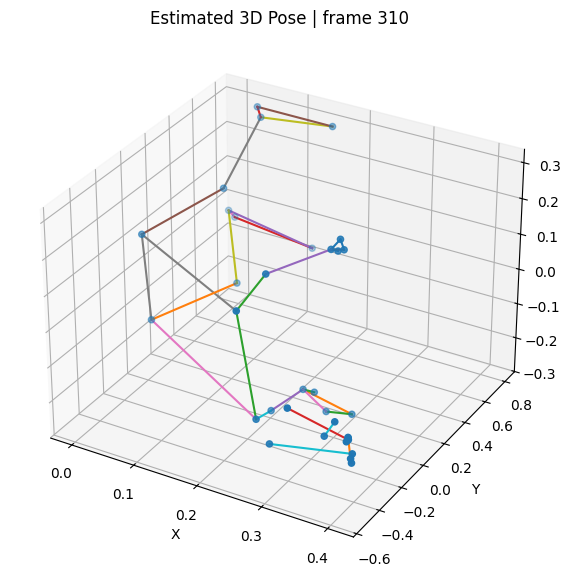

In [26]:
plot_world_pose_3d(
    world_frame_df,
    title=f"Estimated 3D Pose | frame {frame_to_view}"
)

I0000 00:00:1780242778.346964       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M5


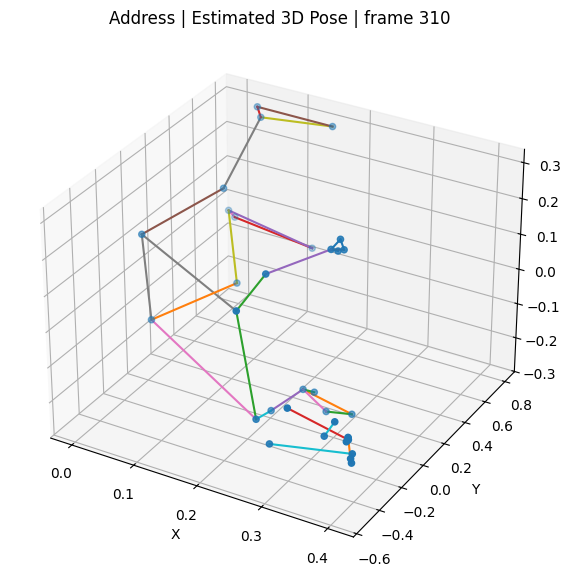

I0000 00:00:1780242778.664047       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M5


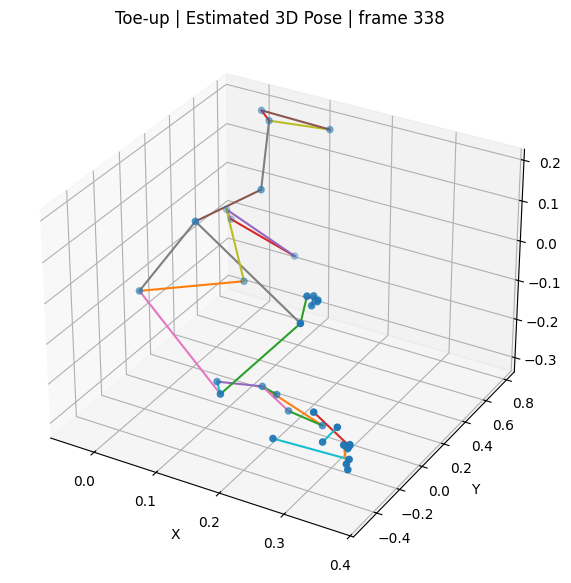

I0000 00:00:1780242779.023654       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M5


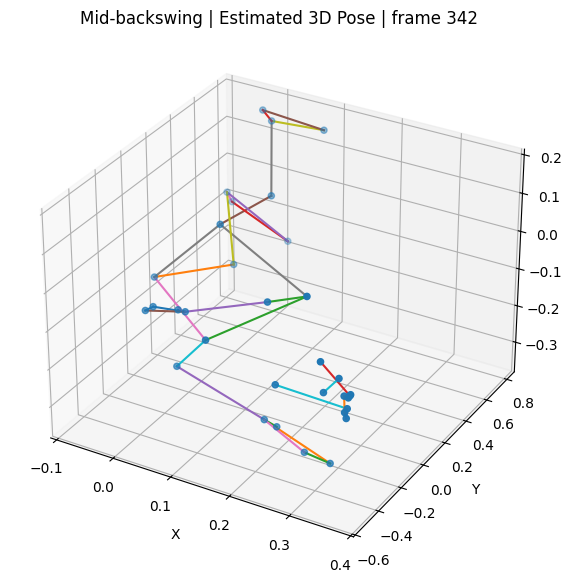

I0000 00:00:1780242779.339514       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M5


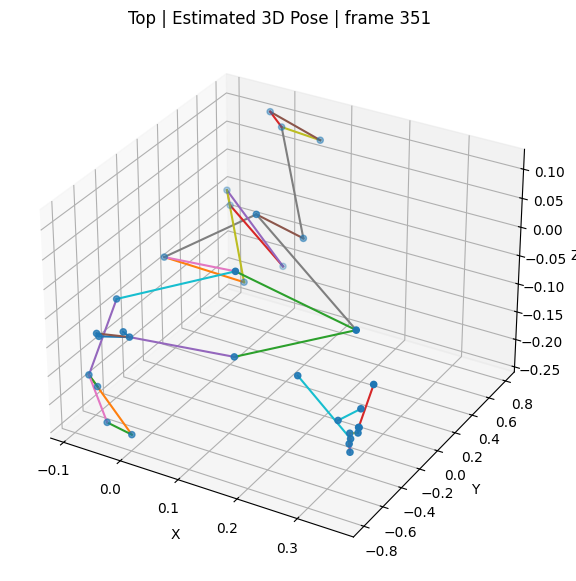

I0000 00:00:1780242779.759557       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M5


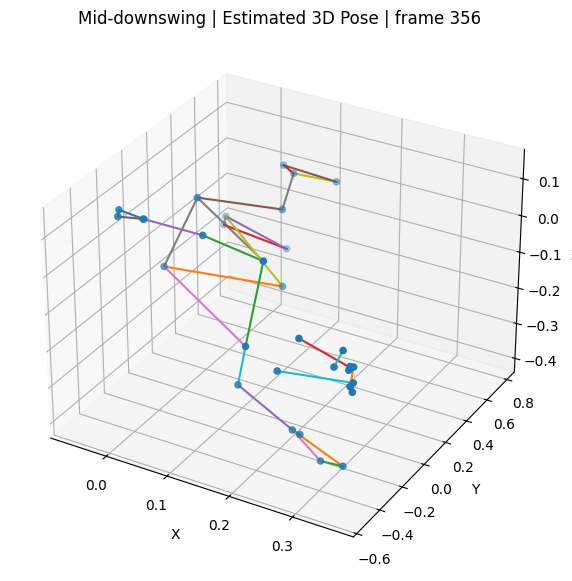

I0000 00:00:1780242780.086843       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M5


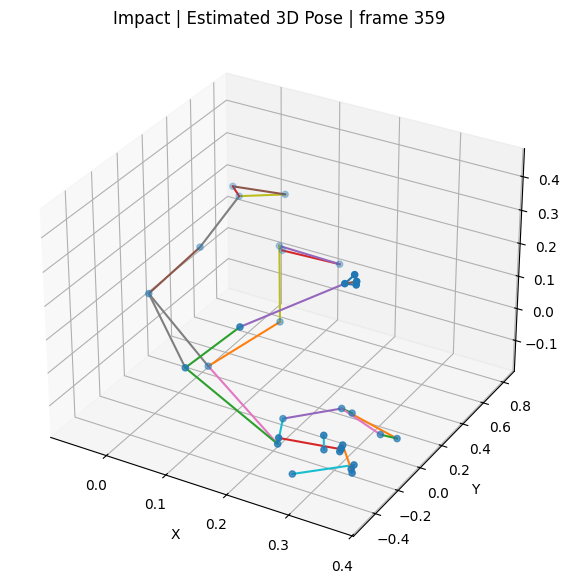

I0000 00:00:1780242780.446731       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M5


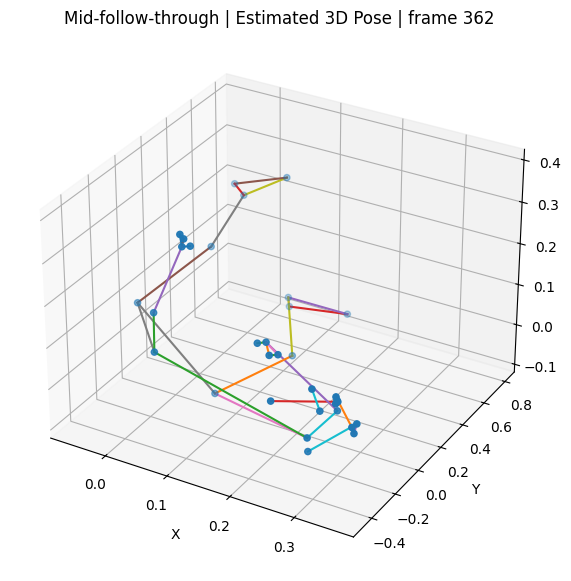

I0000 00:00:1780242780.818254       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M5


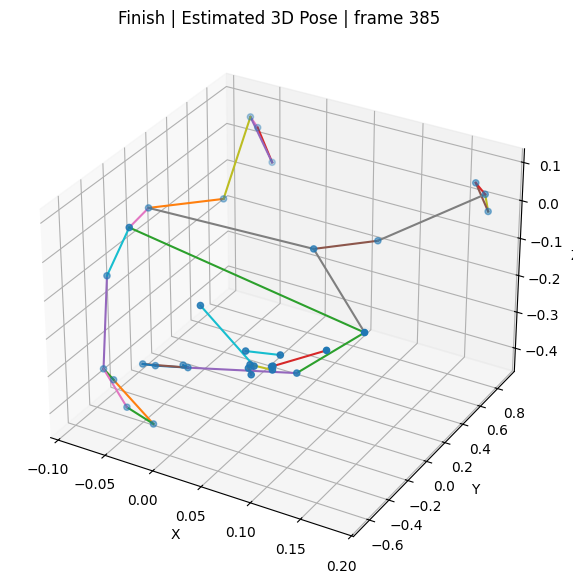

In [27]:
swing_event_names = [
    "Address",
    "Toe-up",
    "Mid-backswing",
    "Top",
    "Mid-downswing",
    "Impact",
    "Mid-follow-through",
    "Finish"
]

swing_event_frames = events_relative[1:9]

for event_name, frame_idx in zip(swing_event_names, swing_event_frames):
    world_frame_df = extract_world_pose_for_frame(
        video_path,
        int(frame_idx),
        video_id="578"
    )

    world_frame_df["joint_name"] = world_frame_df["joint_idx"].map(landmark_names)

    plot_world_pose_3d(
        world_frame_df,
        title=f"{event_name} | Estimated 3D Pose | frame {frame_idx}"
    )